<a href="https://colab.research.google.com/github/YAPrada/MALDI-TOF-Mass-Spectrometry-for-Accurate-Detection-of-Chagas-Disease-in-Clinical-Samples/blob/main/MALDI-TOF%20for%20Accurate%20%20Detection%20of%20Chagas%20Disease%20in%20Clinical%20Samples_Predictivemodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color=#85C1E9 size=8>**Predictive Model-Supporting Information**

<font color=#858FE9 size=4>**Integrating Machine Learning and MALDI-TOF Mass Spectrometry for Accurate Detection of Chagas Disease in Clinical Samples**

<font color=#AD85E9 size=3>**Authors: Yenny F. Velandia, Yuly Andrea Pradaa*, Enrique Mejía-Ospinoa**

<font color=#9085E9 size=3>**Universidad Industrial de Santander (Colombia)**

In [12]:
!pip install openpyxl


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

<font color=#AD85E9 size=4>**Spectrum reading and Loading of Dataset**

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os

ruta = "/content/drive/MyDrive/all spectra"

print(os.listdir(ruta))

['54S D_0_G23_1.txt', '21A D_0_F19_1.txt', '6S D_0_E4_1.txt', '44N D_0_B10_1.txt', '28A_0_G15_1.txt', '18A D_0_F16_1.txt', '14A D_0_P21_1.txt', '37S D_0_G10_1.txt', '1A D_0_P8_2.txt', '48S D_0_G18_1.txt', '5S D_0_E3_1.txt', '60S_0_H4_1.txt', '35N D_0_P5_1.txt', '23S_0_D19_1.txt', '39N D_0_A9_1.txt', '55S_0_F24_1.txt', '15S_0_D12_1.txt', '31N D_0_B7_1.txt', '18N_0_A6_1.txt', '8S_0_D6_1.txt', '9S_0_D7_1.txt', '5A_0_O11_1.txt', '37N D_0_B8_1.txt', '58S_0_H2_1.txt', '29S_0_F1_1.txt', '12S D_0_E10_1.txt', '3A D_0_P10_1.txt', '28S D_0_E24_1.txt', '14N D_0_B5_1.txt', '26S D_0_E22_1.txt', '32A D_0_H19_1.txt', '31N_0_A7_1.txt', '44N_0_A10_1.txt', '37A_0_G24_1.txt', '50S_0_F20_1.txt', '22S D_0_E18_1.txt', '8N D_0_B3_1.txt', '16S D_0_E13_1.txt', '22S_0_D18_1.txt', '11A_0_O20_1.txt', '21A_0_E19_1.txt', '46S_0_F16_1.txt', '33N_0_O3_1.txt', '59S D_0_I3_1.txt', '15N_0_A8_1.txt', '28N_0_A15_1.txt', '27N D_0_B14_1.txt', '61S D_0_I5_1.txt', '30N_0_O2_1.txt', '18N D_0_B6_1.txt', '51S_0_F21_1.txt', '10N D

In [16]:
archivos = sorted([f for f in os.listdir(ruta) if f.endswith(".txt")])

print("Número de archivos:", len(archivos))
print(archivos[:5])

Número de archivos: 236
['10A D_0_P19_1.txt', '10A_0_O19_1.txt', '10N D_0_B4_1.txt', '10N_0_A4_1.txt', '10S D_0_E8_1.txt']


In [17]:
archivo = os.path.join(ruta, archivos[0])

print("Archivo revisado:", archivos[0])

with open(archivo, "r") as f:
    for i in range(15):
        print(f.readline())

Archivo revisado: 10A D_0_P19_1.txt
598.375 267

598.486 381

598.597 588

598.708 735

598.819 803

598.930 624

599.041 405

599.153 171

599.264 71

599.375 94

599.486 162

599.597 320

599.708 537

599.819 627

599.930 578



In [18]:
import glob
fn = []
all_spectra = pd.DataFrame()

In [19]:
import os
import re
import pandas as pd
import numpy as np

# Leer todos los espectros
espectros = []
clases = []
nombres = []

for archivo in archivos:
    path = os.path.join(ruta, archivo)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["mz", "intensity"]
    )

    espectros.append(df["intensity"].values)
    nombres.append(archivo)

    # Clase desde el nombre: 10A, 10N, 10S
    clase = re.search(r"^\d+\s*([ANS])", archivo.upper()).group(1)
    clases.append(clase)

# Crear matriz
Dataint = pd.DataFrame(espectros, index=nombres)
Dataint["Clase"] = clases

print("Dataint:", Dataint.shape)
print(Dataint["Clase"].value_counts())
Dataint.head()

Dataint: (236, 23041)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,23031,23032,23033,23034,23035,23036,23037,23038,23039,Clase
10A D_0_P19_1.txt,267,381,588,735,803,624,405,171,71,94,...,11,10,4,-3,9,7,15,-1,3,A
10A_0_O19_1.txt,234,415,535,561,432,267,83,-33,27,331,...,9,16,13,7,15,14,4,1,8,A
10N D_0_B4_1.txt,776,896,994,910,814,710,595,629,685,702,...,2,0,4,2,-5,-2,3,-4,-7,N
10N_0_A4_1.txt,823,879,939,882,856,773,725,680,685,882,...,-1,5,5,11,11,14,14,29,36,N
10S D_0_E8_1.txt,872,999,1025,854,548,253,192,350,622,971,...,11,12,-9,3,-6,0,17,2,-2,S


In [20]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


Principal Components Analysis (Exploratory Analysis)

In [21]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = le.classes_

print("Classes:", class_names)
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

Classes: ['A' 'N' 'S']
X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


Explained variance: [0.14704836 0.05993323 0.05191248 0.03074688 0.02940873 0.02716257
 0.02259433 0.02109656 0.01834517 0.01444425]
Total variance PC1-PC10: 0.42269255215518725


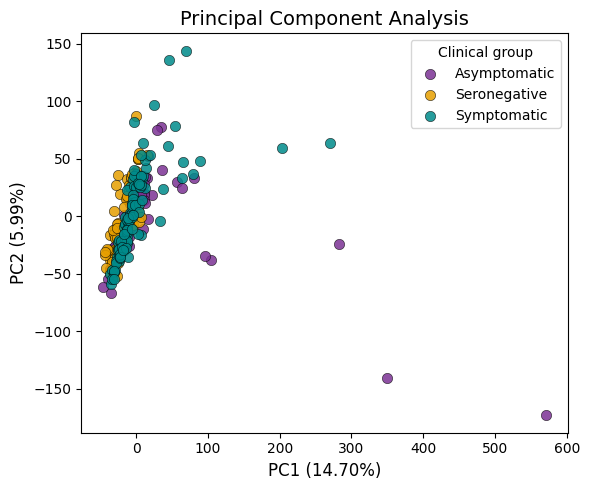

In [22]:
from sklearn.decomposition import PCA

X_scaled_pca = StandardScaler().fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled_pca)

pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(10)])
pca_df["Class"] = y.values

print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance PC1-PC10:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(6,5))

colors = {
    "A": "#7B3294",
    "N": "#E69F00",
    "S": "#008B8B"
}

labels = {
    "A": "Asymptomatic",
    "N": "Seronegative",
    "S": "Symptomatic"
}

for class_name in class_names:

    subset = pca_df[pca_df["Class"] == class_name]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
        color=colors[class_name],
        label=labels[class_name]
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)

plt.title("Principal Component Analysis", fontsize=14)

plt.legend(title="Clinical group")

plt.tight_layout()

plt.savefig("figures/PCA_PC1_PC2.png", dpi=600)

plt.show()

In [24]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance PC1-PC10:", pca.explained_variance_ratio_.sum())

Explained variance: [0.14704836 0.05993323 0.05191248 0.03074688 0.02940873 0.02716257
 0.02259433 0.02109656 0.01834517 0.01444425]
Total variance PC1-PC10: 0.42269255215518725


In [25]:
explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(10)],
    "Explained Variance": explained,
    "Cumulative Variance": cum_explained
})

display(variance_df)

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.147048,0.147048
1,PC2,0.059933,0.206982
2,PC3,0.051912,0.258894
3,PC4,0.030747,0.289641
4,PC5,0.029409,0.319050
5,PC6,0.027163,0.346212
6,PC7,0.022594,0.368807
7,PC8,0.021097,0.389903
8,PC9,0.018345,0.408248
9,PC10,0.014444,0.422693


Linear Discriminant Analysis (LDA)

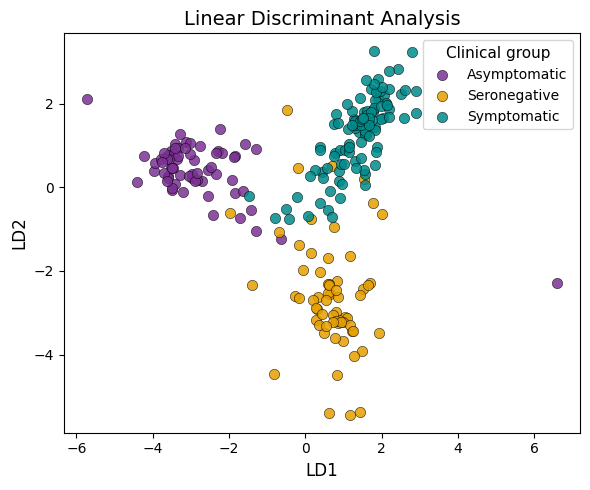

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2))
])

X_lda = lda_pipe.fit_transform(X, y_encoded)

lda_df = pd.DataFrame(X_lda, columns=["LD1", "LD2"])
lda_df["Class"] = y.values

colors = {
    "A": "#7B3294",
    "N": "#E69F00",
    "S": "#008B8B"
}

labels = {
    "A": "Asymptomatic",
    "N": "Seronegative",
    "S": "Symptomatic"
}

plt.figure(figsize=(6, 5))

for class_name in class_names:
    subset = lda_df[lda_df["Class"] == class_name]

    plt.scatter(
        subset["LD1"],
        subset["LD2"],
        s=55,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
        color=colors[class_name],
        label=labels[class_name]
    )

plt.xlabel("LD1", fontsize=12)
plt.ylabel("LD2", fontsize=12)
plt.title("Linear Discriminant Analysis", fontsize=14)
plt.legend(title="Clinical group", fontsize=10, title_fontsize=11)
plt.tight_layout()

plt.savefig("figures/LDA.png", dpi=600, bbox_inches="tight")
plt.show()

In [27]:
lda_df.to_excel("LDA_coordinates.xlsx", index=False)

Sample similarity network

Number of nodes: 236
Number of edges: 35


NameError: name 'edge_labels' is not defined

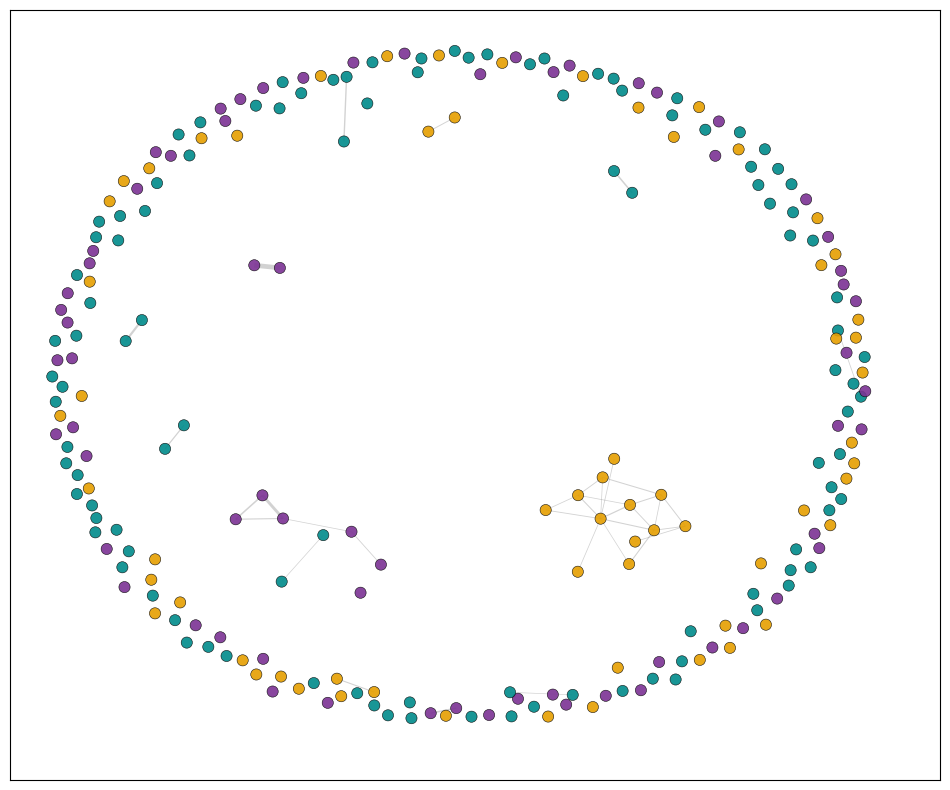

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

os.makedirs("figures", exist_ok=True)

colors = {
    "A": "#7B3294",
    "N": "#E69F00",
    "S": "#008B8B"
}

labels = {
    "A": "Asymptomatic",
    "N": "Seronegative",
    "S": "Symptomatic"
}

X_scaled_net = StandardScaler().fit_transform(X)

corr_matrix, p_matrix = spearmanr(X_scaled_net, axis=1)

corr_df = pd.DataFrame(
    corr_matrix,
    index=X.index,
    columns=X.index
)

threshold = 0.40

G = nx.Graph()

for i, sample in enumerate(X.index):
    group = y.iloc[i]
    G.add_node(sample, group=group)

for i in range(len(X.index)):
    for j in range(i + 1, len(X.index)):
        rho = corr_matrix[i, j]

        if rho >= threshold:
            G.add_edge(
                X.index[i],
                X.index[j],
                weight=rho,
                label=f"{rho:.2f}"
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    seed=12,
    k=0.35,
    iterations=100
)

node_colors = [
    colors[G.nodes[node]["group"]]
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=65,
    alpha=0.90,
    edgecolors="black",
    linewidths=0.4
)

edges = G.edges(data=True)
edge_weights = [d["weight"] for _, _, d in edges]

edge_widths = [
    0.5 + 3.0 * (w - threshold) / (1 - threshold)
    for w in edge_weights
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35,
    edge_color="gray"
)


edges_table = []

for u, v, d in G.edges(data=True):

    g1 = G.nodes[u]["group"]
    g2 = G.nodes[v]["group"]

    # Ordena las parejas para evitar que A-N y N-A cuenten diferente
    connection = "-".join(sorted([g1, g2]))

    edges_table.append({
        "Sample 1": u,
        "Sample 2": v,
        "Group 1": g1,
        "Group 2": g2,
        "Connection": connection,
        "Spearman rho": d["weight"]
    })

edges_df = pd.DataFrame(edges_table)
edges_df = edges_df.sort_values("Spearman rho", ascending=False)

edges_df.to_excel("sample_similarity_network_edges.xlsx", index=False)

edges_df.head()

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6,
    font_color="black"
)


legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=labels[group],
        markerfacecolor=colors[group],
        markeredgecolor="black",
        markersize=9
    )
    for group in ["A", "N", "S"]
]

plt.legend(
    handles=legend_handles,
    title="Clinical group",
    loc="upper right",
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

plt.title(
    f"Sample Similarity Network\nSpearman correlation threshold ≥ {threshold}",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "figures/sample_similarity_network_spearman.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [30]:
connection_summary = (
    edges_df["Connection"]
    .value_counts()
    .rename_axis("Connection")
    .reset_index(name="Number of edges")
)

print(connection_summary)

connection_summary.to_excel(
    "sample_similarity_network_summary.xlsx",
    index=False
)

  Connection  Number of edges
0        N-N               21
1        A-A                7
2        S-S                7


In [31]:
corr_df.to_excel("sample_similarity_spearman_correlation_matrix.xlsx")

In [32]:
edges_table = []

for u, v, d in G.edges(data=True):
    edges_table.append({
        "Sample 1": u,
        "Sample 2": v,
        "Group 1": G.nodes[u]["group"],
        "Group 2": G.nodes[v]["group"],
        "Spearman rho": d["weight"]
    })

edges_df = pd.DataFrame(edges_table)
edges_df = edges_df.sort_values("Spearman rho", ascending=False)

edges_df.to_excel("sample_similarity_network_edges.xlsx", index=False)

edges_df.head()

,Sample 1,Sample 2,Group 1,Group 2,Spearman rho
34,9A DD_0_P14_1.txt,9A_0_O14_1.txt,A,A,0.982653
13,30A D_0_H17_1.txt,30A_0_G17_1.txt,A,A,0.716115
23,44S D_0_G14_1.txt,44S_0_F14_1.txt,S,S,0.616638
14,30A D_0_H17_1.txt,34A_0_G21_1.txt,A,A,0.524684
0,13S D_0_E11_1.txt,13S_0_D11_1.txt,S,S,0.522598


Trainning Models Machine Learning

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=12,
    shuffle=True,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train: (188, 23040)
Test: (48, 23040)
Clase
S    84
A    53
N    51
Name: count, dtype: int64
Clase
S    22
N    13
A    13
Name: count, dtype: int64


In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=40, probability=True, random_state=123))
])

svc_pipeline.fit(X_train, y_train)

y_pred = svc_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48

[[11  2  0]
 [ 0 13  0]
 [ 0  0 22]]


In [36]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = le.classes_

print("Classes:", class_names)
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

Classes: ['A' 'N' 'S']
X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    train_size=0.8,
    random_state=12,
    shuffle=True,
    stratify=y_encoded
)

Models defined


In [38]:
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "SVC RBF": SVC(kernel="rbf", C=40, probability=True, random_state=123),
    "NuSVC": NuSVC(nu=0.1, kernel="rbf", probability=True, random_state=123),
    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    random_state=123,
    class_weight="balanced",
    n_jobs=-1
),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=123),
    "Linear SVC": LinearSVC(C=1.0, max_iter=10000, random_state=123),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=123
    ),
    "SGD Classifier": SGDClassifier(loss="log_loss", max_iter=5000, random_state=123),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight="balanced", multi_class="auto"),
    "Bagging Classifier": BaggingClassifier(
    n_estimators=300,
    random_state=123,
    n_jobs=-1
),
    "ExtraTrees Classifier": ExtraTreesClassifier(
    n_estimators=300,
    random_state=123,
    class_weight="balanced",
    n_jobs=-1
)}

Metrics and confusion matrix


SVC RBF
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48



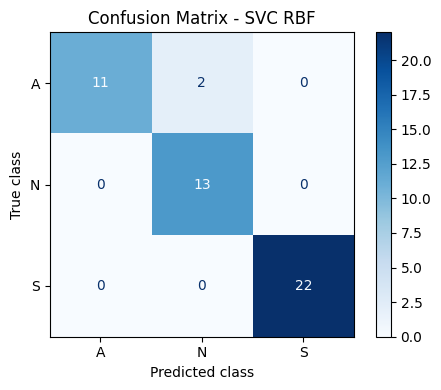


NuSVC
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48



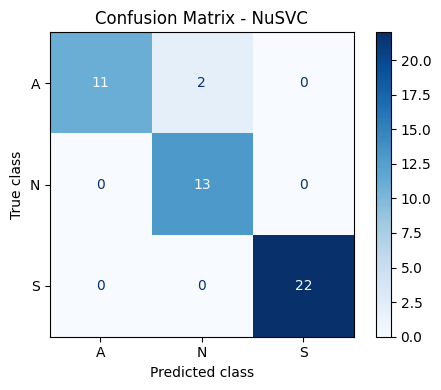


Random Forest
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



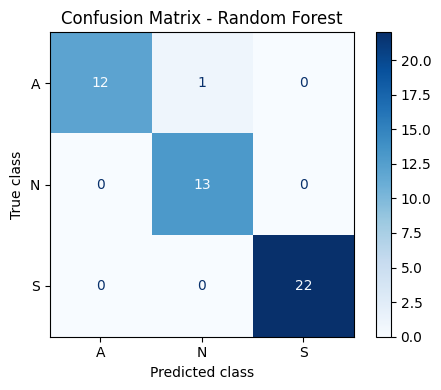


Neural Network
              precision    recall  f1-score   support

           A     0.9091    0.7692    0.8333        13
           N     0.6842    1.0000    0.8125        13
           S     1.0000    0.8182    0.9000        22

    accuracy                         0.8542        48
   macro avg     0.8644    0.8625    0.8486        48
weighted avg     0.8899    0.8542    0.8582        48



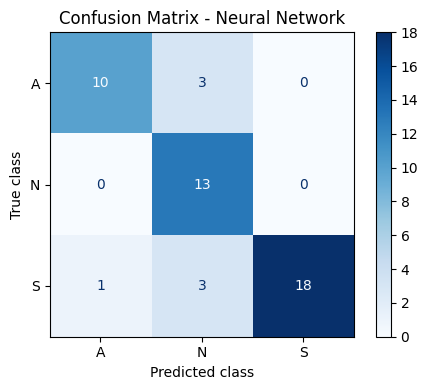


Linear SVC
              precision    recall  f1-score   support

           A     1.0000    0.7692    0.8696        13
           N     0.7647    1.0000    0.8667        13
           S     1.0000    0.9545    0.9767        22

    accuracy                         0.9167        48
   macro avg     0.9216    0.9079    0.9043        48
weighted avg     0.9363    0.9167    0.9179        48



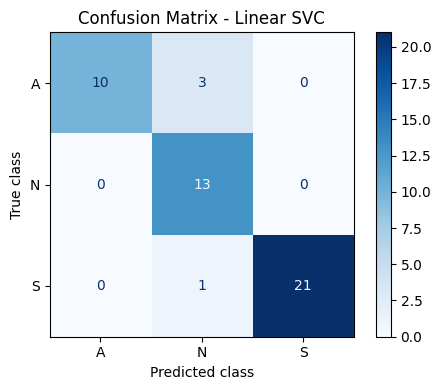


XGBoost
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



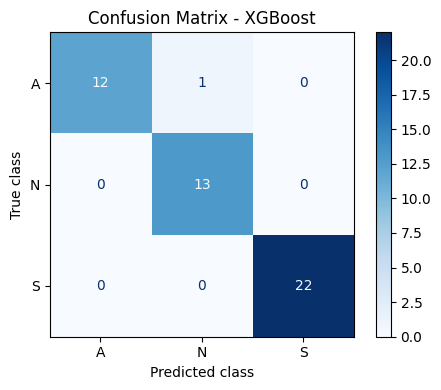


SGD Classifier
              precision    recall  f1-score   support

           A     1.0000    0.6154    0.7619        13
           N     0.6842    1.0000    0.8125        13
           S     1.0000    0.9545    0.9767        22

    accuracy                         0.8750        48
   macro avg     0.8947    0.8566    0.8504        48
weighted avg     0.9145    0.8750    0.8741        48



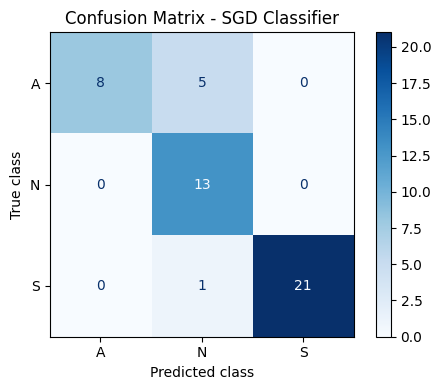


KNN
              precision    recall  f1-score   support

           A     1.0000    0.2308    0.3750        13
           N     0.3939    1.0000    0.5652        13
           S     1.0000    0.5455    0.7059        22

    accuracy                         0.5833        48
   macro avg     0.7980    0.5921    0.5487        48
weighted avg     0.8359    0.5833    0.5782        48



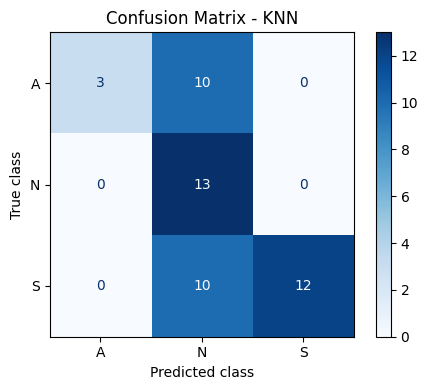

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.7647    1.0000    0.8667        13
           S     1.0000    0.9091    0.9524        22

    accuracy                         0.9167        48
   macro avg     0.9216    0.9184    0.9119        48
weighted avg     0.9363    0.9167    0.9195        48



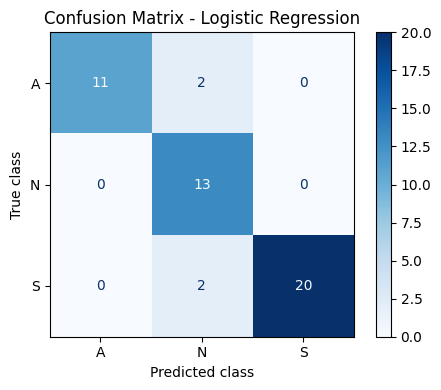


Bagging Classifier
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



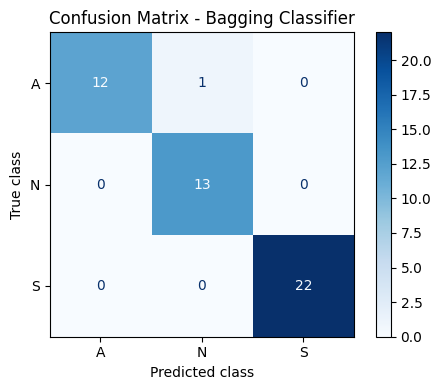


ExtraTrees Classifier
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



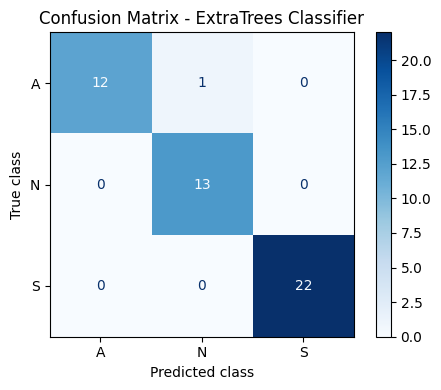

,Model,Accuracy,Balanced accuracy,Precision macro,Recall macro,F1 macro
2,Random Forest,0.979167,0.974359,0.976190,0.974359,0.974321
10,ExtraTrees Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
5,XGBoost,0.979167,0.974359,0.976190,0.974359,0.974321
9,Bagging Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
0,SVC RBF,0.958333,0.948718,0.955556,0.948718,0.948413
1,NuSVC,0.958333,0.948718,0.955556,0.948718,0.948413
4,Linear SVC,0.916667,0.907925,0.921569,0.907925,0.904325
8,Logistic Regression,0.916667,0.918415,0.921569,0.918415,0.911905
6,SGD Classifier,0.875000,0.856643,0.894737,0.856643,0.850383
3,Neural Network,0.854167,0.862471,0.864434,0.862471,0.848611


In [39]:
os.makedirs("figures", exist_ok=True)

results = []

trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Balanced accuracy": bal_acc,
        "Precision macro": prec,
        "Recall macro": rec,
        "F1 macro": f1
    })

    trained_models[name] = pipe

    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=True)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    plt.tight_layout()
    plt.savefig(f"figures/confusion_matrix_{name.replace(' ', '_')}.png", dpi=600)
    plt.show()

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

Models comparations

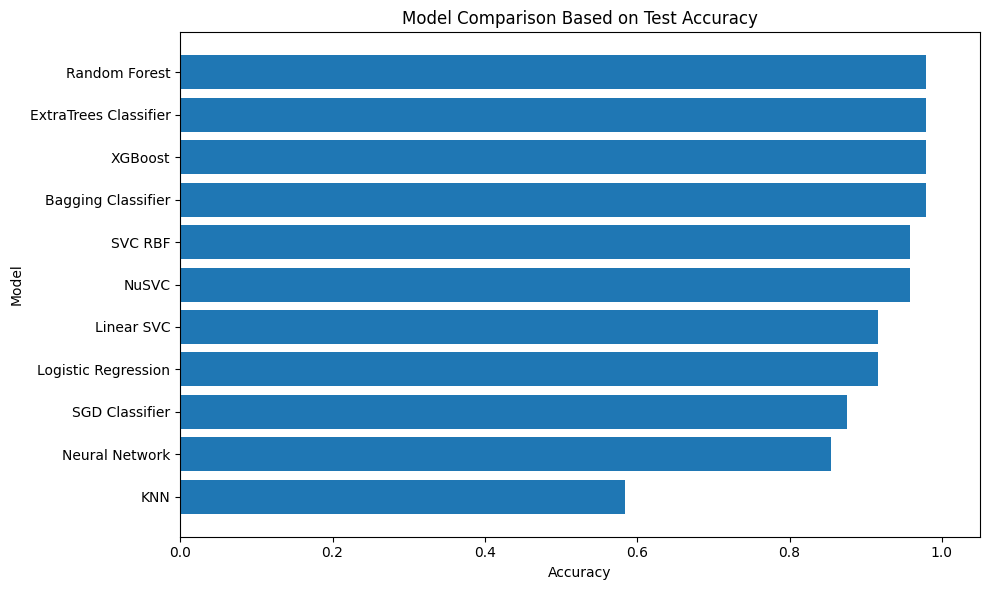

,Model,Accuracy,Balanced accuracy,Precision macro,Recall macro,F1 macro
2,Random Forest,0.979167,0.974359,0.976190,0.974359,0.974321
10,ExtraTrees Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
5,XGBoost,0.979167,0.974359,0.976190,0.974359,0.974321
9,Bagging Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
0,SVC RBF,0.958333,0.948718,0.955556,0.948718,0.948413
1,NuSVC,0.958333,0.948718,0.955556,0.948718,0.948413
4,Linear SVC,0.916667,0.907925,0.921569,0.907925,0.904325
8,Logistic Regression,0.916667,0.918415,0.921569,0.918415,0.911905
6,SGD Classifier,0.875000,0.856643,0.894737,0.856643,0.850383
3,Neural Network,0.854167,0.862471,0.864434,0.862471,0.848611


In [40]:
results_df.to_excel("model_comparison_metrics.xlsx", index=False)

plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison Based on Test Accuracy")
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/model_comparison_accuracy.png", dpi=600)
plt.show()

results_df

ROC Multi-Class Curve

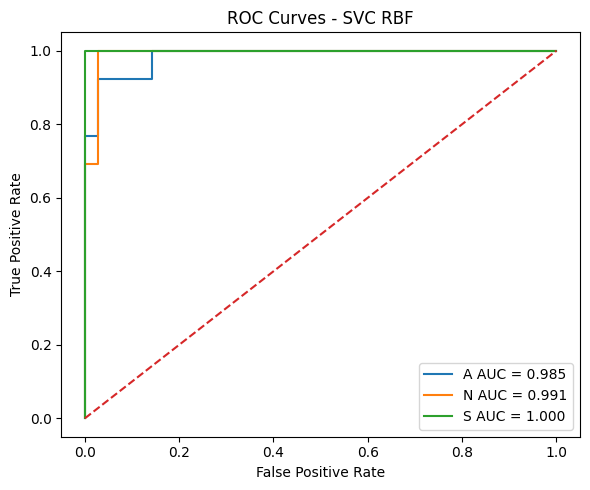

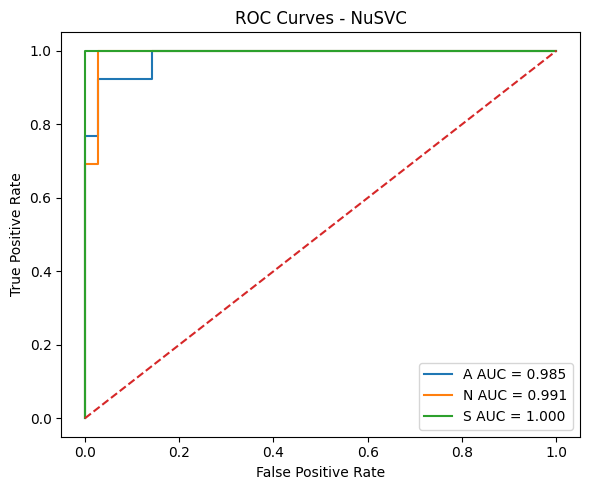

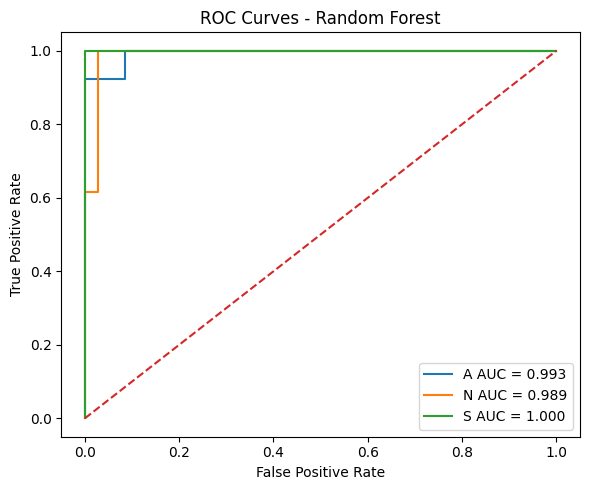

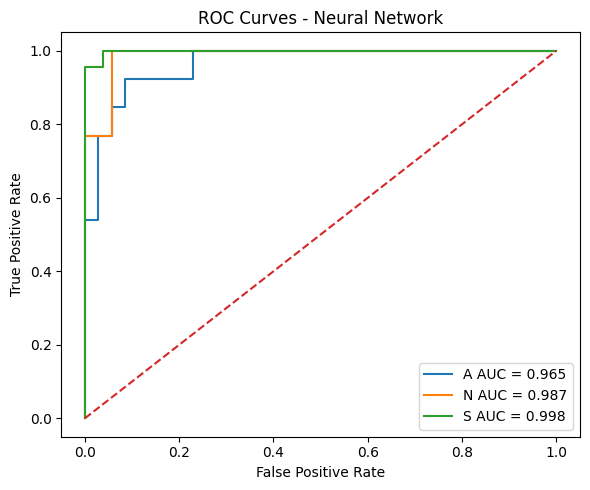

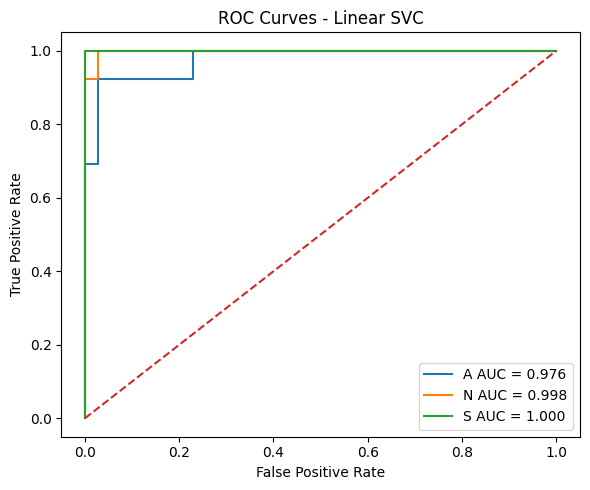

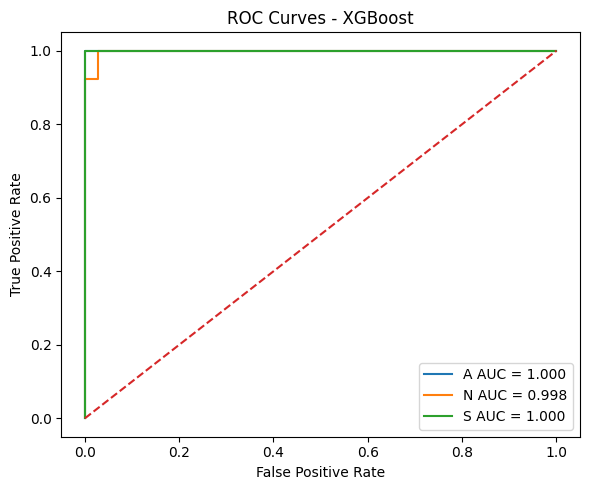

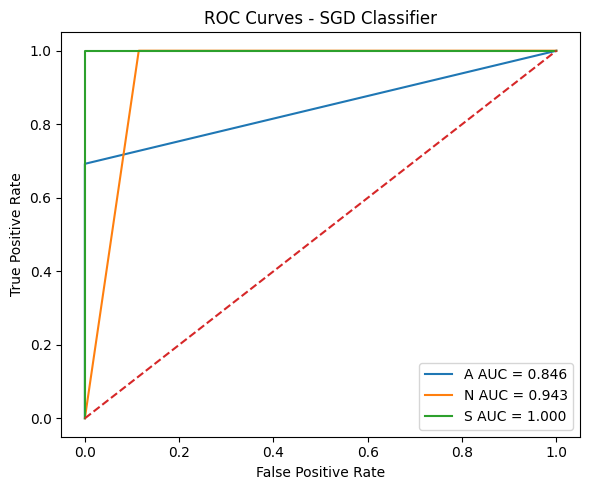

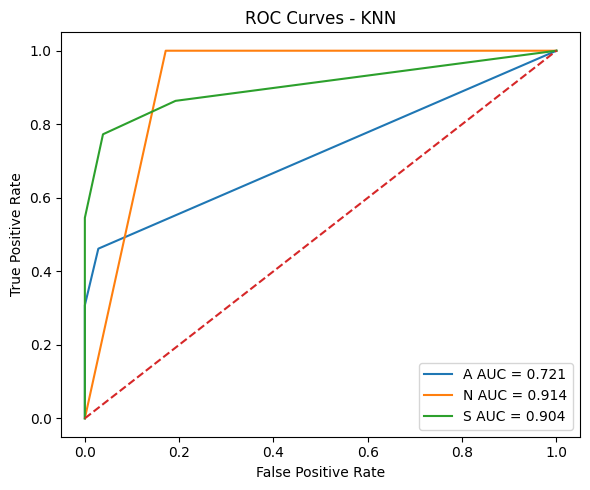

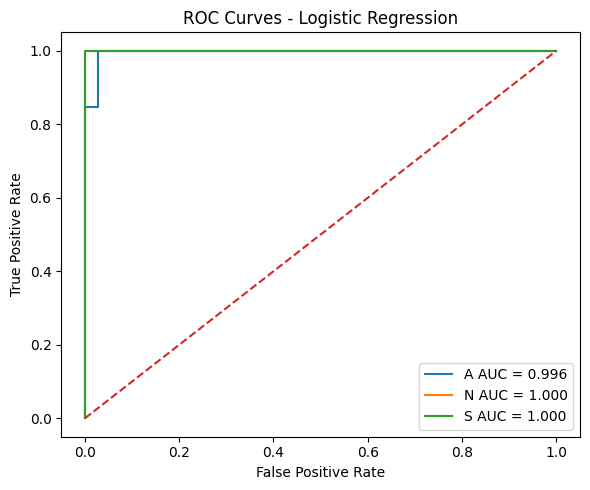

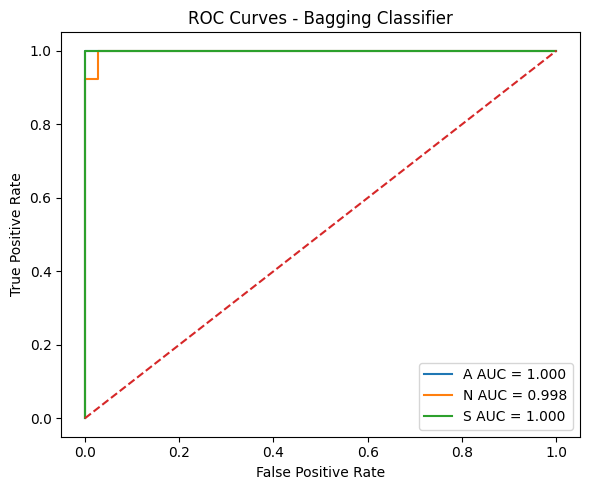

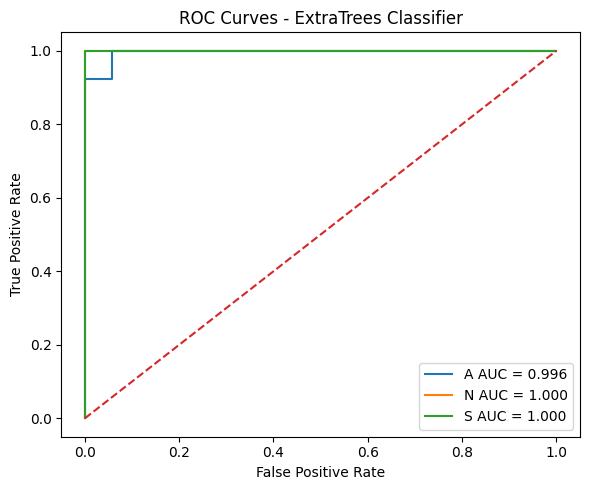

In [42]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

for name, pipe in trained_models.items():

    model = pipe.named_steps["model"]

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)
    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        continue

    plt.figure(figsize=(6, 5))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} AUC = {roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"figures/roc_{name.replace(' ', '_')}.png", dpi=600)
    plt.show()

In [43]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# Binarizar clases para ROC multiclase
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

auc_rows = []

for model_name, pipe in trained_models.items():

    # Obtener scores del modelo
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)

    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(X_test)

    else:
        print(f"{model_name} does not provide probability or decision scores.")
        continue

    # AUC por clase
    row = {"Model": model_name}

    for i, class_name in enumerate(class_names):
        auc_value = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        row[f"AUC_{class_name}"] = auc_value

    # AUC promedio macro y weighted
    row["AUC_macro"] = roc_auc_score(
        y_test_bin,
        y_score,
        average="macro",
        multi_class="ovr"
    )

    row["AUC_weighted"] = roc_auc_score(
        y_test_bin,
        y_score,
        average="weighted",
        multi_class="ovr"
    )

    auc_rows.append(row)

auc_table = pd.DataFrame(auc_rows)

# Ordenar por AUC macro
auc_table = auc_table.sort_values("AUC_macro", ascending=False)

auc_table

,Model,AUC_A,AUC_N,AUC_S,AUC_macro,AUC_weighted
5,XGBoost,1.000000,0.997802,1.000000,0.999267,0.999405
9,Bagging Classifier,1.000000,0.997802,1.000000,0.999267,0.999405
8,Logistic Regression,0.995604,1.000000,1.000000,0.998535,0.998810
10,ExtraTrees Classifier,0.995604,1.000000,1.000000,0.998535,0.998810
2,Random Forest,0.993407,0.989011,1.000000,0.994139,0.995238
1,NuSVC,0.984615,0.991209,1.000000,0.991941,0.993452
0,SVC RBF,0.984615,0.991209,1.000000,0.991941,0.993452
4,Linear SVC,0.975824,0.997802,1.000000,0.991209,0.992857
3,Neural Network,0.964835,0.986813,0.998252,0.983300,0.986103
6,SGD Classifier,0.846154,0.942857,1.000000,0.929670,0.942857


In [44]:
auc_table.to_excel("ROC_AUC_by_class_models.xlsx", index=False)
auc_table.to_csv("ROC_AUC_by_class_models.csv", index=False)

In [45]:
auc_table_rounded = auc_table.copy()

numeric_cols = auc_table_rounded.select_dtypes(include=np.number).columns
auc_table_rounded[numeric_cols] = auc_table_rounded[numeric_cols].round(4)

auc_table_rounded

,Model,AUC_A,AUC_N,AUC_S,AUC_macro,AUC_weighted
5,XGBoost,1.0000,0.9978,1.0000,0.9993,0.9994
9,Bagging Classifier,1.0000,0.9978,1.0000,0.9993,0.9994
8,Logistic Regression,0.9956,1.0000,1.0000,0.9985,0.9988
10,ExtraTrees Classifier,0.9956,1.0000,1.0000,0.9985,0.9988
2,Random Forest,0.9934,0.9890,1.0000,0.9941,0.9952
1,NuSVC,0.9846,0.9912,1.0000,0.9919,0.9935
0,SVC RBF,0.9846,0.9912,1.0000,0.9919,0.9935
4,Linear SVC,0.9758,0.9978,1.0000,0.9912,0.9929
3,Neural Network,0.9648,0.9868,0.9983,0.9833,0.9861
6,SGD Classifier,0.8462,0.9429,1.0000,0.9297,0.9429


Cross-Validadation and Hyperparameters

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)

cv_summary = []
hyperparams_summary = []

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [47]:
# Hiperparámetros principales para reportar de forma limpia
main_params = {
    "SVC RBF": ["C", "kernel", "gamma", "probability", "random_state"],
    "NuSVC": ["nu", "kernel", "gamma", "probability", "random_state"],
    "Random Forest": ["n_estimators", "criterion", "max_depth", "class_weight", "random_state"],
    "Neural Network": ["hidden_layer_sizes", "activation", "solver", "max_iter", "random_state"],
    "Linear SVC": ["C", "loss", "max_iter", "random_state"],
    "XGBoost": ["n_estimators", "learning_rate", "max_depth", "objective", "eval_metric", "random_state"],
    "SGD Classifier": ["loss", "penalty", "alpha", "max_iter", "random_state"],
    "KNN": ["n_neighbors", "weights", "metric"],
    "Logistic Regression": ["C", "penalty", "solver", "max_iter", "class_weight", "random_state"],
    "Bagging Classifier": ["n_estimators", "random_state"],
    "ExtraTrees Classifier": ["n_estimators", "criterion", "max_depth", "class_weight", "random_state"]
}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

In [48]:
X.shape

(236, 23040)

In [49]:
print(type(X))
print(X.shape)

print(type(y))
print(len(y))

print(type(y_encoded))
print(len(y_encoded))

<class 'pandas.core.frame.DataFrame'>
(236, 23040)
<class 'pandas.core.series.Series'>
236
<class 'numpy.ndarray'>
236


In [50]:
cv_results = cross_validate(
    pipe,
    X,
    y_encoded,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

row = {"Model": name}

for metric in scoring:
    values = cv_results[f"test_{metric}"]
    row[f"{metric}_mean"] = values.mean()
    row[f"{metric}_sd"] = values.std()

cv_summary.append(row)

In [51]:
models_no_xgb = {
    name: pipe for name, pipe in models.items()
    if name != "XGBoost"
}

cv_summary = []

for name, pipe in models_no_xgb.items():
    print(f"Running cross-validation for: {name}")

    cv_results = cross_validate(
        pipe,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    row = {"Model": name}

    for metric in scoring:
        values = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_sd"] = values.std()

    cv_summary.append(row)

cv_results_df = pd.DataFrame(cv_summary).round(4)
display(cv_results_df)

Running cross-validation for: SVC RBF
Running cross-validation for: NuSVC
Running cross-validation for: Random Forest
Running cross-validation for: Neural Network
Running cross-validation for: Linear SVC
Running cross-validation for: SGD Classifier
Running cross-validation for: KNN
Running cross-validation for: Logistic Regression
Running cross-validation for: Bagging Classifier
Running cross-validation for: ExtraTrees Classifier


,Model,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,precision_macro_mean,precision_macro_sd,recall_macro_mean,recall_macro_sd,f1_macro_mean,f1_macro_sd
0,SVC RBF,0.9580,0.0264,0.9535,0.0295,0.9634,0.0298,0.9535,0.0295,0.9552,0.0315
1,NuSVC,0.9453,0.0328,0.9418,0.0360,0.9492,0.0337,0.9418,0.0360,0.9424,0.0363
2,Random Forest,0.9281,0.0560,0.9212,0.0575,0.9366,0.0600,0.9212,0.0575,0.9253,0.0588
3,Neural Network,0.9324,0.0463,0.9296,0.0425,0.9358,0.0441,0.9296,0.0425,0.9296,0.0437
4,Linear SVC,0.9571,0.0431,0.9529,0.0501,0.9637,0.0370,0.9529,0.0501,0.9551,0.0467
5,SGD Classifier,0.9069,0.0559,0.9080,0.0596,0.9075,0.0528,0.9080,0.0596,0.9019,0.0597
6,KNN,0.8563,0.0557,0.8476,0.0591,0.8588,0.0644,0.8476,0.0591,0.8480,0.0616
7,Logistic Regression,0.9156,0.0413,0.9166,0.0387,0.9232,0.0389,0.9166,0.0387,0.9133,0.0424
8,Bagging Classifier,0.9072,0.0639,0.9048,0.0593,0.9174,0.0626,0.9048,0.0593,0.9059,0.0663
9,ExtraTrees Classifier,0.9324,0.0532,0.9252,0.0550,0.9370,0.0560,0.9252,0.0550,0.9286,0.0551


Hyperparameters table

In [53]:
params = model.get_params()
selected_keys = main_params.get(name, list(params.keys()))
selected_params = {
        key: params.get(key, "NA")
        for key in selected_keys
        if key in params
    }
hyperparams_text = "; ".join(
        [f"{key}={value}" for key, value in selected_params.items()]
    )
hyperparams_summary.append({
        "Model": name,
        "Hyperparameters reported": hyperparams_text
    })

Final CV Table


In [54]:
cv_df = pd.DataFrame(cv_summary).sort_values("accuracy_mean", ascending=False)

numeric_cols = cv_df.select_dtypes(include=np.number).columns
cv_df[numeric_cols] = cv_df[numeric_cols].round(4)

cv_df.to_excel("cross_validation_metrics.xlsx", index=False)

 Final hyperparameters table

In [55]:
hyperparams_df = pd.DataFrame(hyperparams_summary)

hyperparams_df.to_excel("hyperparameters_table.xlsx", index=False)

print("Cross-validation metrics:")
display(cv_df)

print("\nHyperparameters table:")
display(hyperparams_df)

Cross-validation metrics:


,Model,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,precision_macro_mean,precision_macro_sd,recall_macro_mean,recall_macro_sd,f1_macro_mean,f1_macro_sd
0,SVC RBF,0.9580,0.0264,0.9535,0.0295,0.9634,0.0298,0.9535,0.0295,0.9552,0.0315
4,Linear SVC,0.9571,0.0431,0.9529,0.0501,0.9637,0.0370,0.9529,0.0501,0.9551,0.0467
1,NuSVC,0.9453,0.0328,0.9418,0.0360,0.9492,0.0337,0.9418,0.0360,0.9424,0.0363
3,Neural Network,0.9324,0.0463,0.9296,0.0425,0.9358,0.0441,0.9296,0.0425,0.9296,0.0437
9,ExtraTrees Classifier,0.9324,0.0532,0.9252,0.0550,0.9370,0.0560,0.9252,0.0550,0.9286,0.0551
2,Random Forest,0.9281,0.0560,0.9212,0.0575,0.9366,0.0600,0.9212,0.0575,0.9253,0.0588
7,Logistic Regression,0.9156,0.0413,0.9166,0.0387,0.9232,0.0389,0.9166,0.0387,0.9133,0.0424
8,Bagging Classifier,0.9072,0.0639,0.9048,0.0593,0.9174,0.0626,0.9048,0.0593,0.9059,0.0663
5,SGD Classifier,0.9069,0.0559,0.9080,0.0596,0.9075,0.0528,0.9080,0.0596,0.9019,0.0597
6,KNN,0.8563,0.0557,0.8476,0.0591,0.8588,0.0644,0.8476,0.0591,0.8480,0.0616



Hyperparameters table:


,Model,Hyperparameters reported
0,ExtraTrees Classifier,n_estimators=300; criterion=gini; max_depth=No...
